In [216]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [217]:
df = pd.read_csv(r'C:\Users\123\Desktop\Social_Network_Ads.csv')

In [218]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [219]:
df=df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [220]:
df.sample(5)

,Age,EstimatedSalary,Purchased
207,52,114000,0
187,33,41000,0
16,47,25000,1
177,25,22000,0
183,33,43000,0


In [221]:
df.shape

(400, 3)

In [222]:
x=df.drop('Purchased',axis=1)
y=df['Purchased']

In [223]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [224]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

Train test Split

In [225]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

x_train.shape , x_test.shape

((280, 2), (120, 2))

Standardscaler

In [226]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

# transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [227]:
scaler.mean_

array([3.77607143e+01, 6.90642857e+04])

In [228]:
x_train

,Age,EstimatedSalary
113,37,55000
149,20,74000
356,54,70000
287,48,138000
125,39,61000
...,...,...
159,32,135000
31,27,137000
274,57,26000
271,59,76000


In [229]:
x_train_scaled

array([[-6.91691486e-02, -4.11443994e-01],
       [-1.61492101e+00,  1.44391976e-01],
       [ 1.47658272e+00,  2.73738767e-02],
       [ 9.31023235e-01,  2.01668156e+00],
       [ 1.12684012e-01, -2.35916846e-01],
       [-3.41948890e-01, -7.62498291e-01],
       [ 2.03610592e-01, -3.52934945e-01],
       [-6.91691486e-02,  1.73646500e-01],
       [-4.32875470e-01, -1.88064802e-03],
       [-6.14728630e-01,  2.02901025e-01],
       [ 1.29472956e+00,  6.12464371e-01],
       [ 9.31023235e-01, -1.14280711e+00],
       [-1.60095729e-01, -5.57716618e-01],
       [-2.51022309e-01,  2.32155550e-01],
       [ 2.94537173e-01, -4.99207568e-01],
       [ 6.58243494e-01,  2.90664599e-01],
       [-1.06936153e+00,  4.95446272e-01],
       [-3.41948890e-01, -7.62498291e-01],
       [ 4.76390333e-01,  1.25606391e+00],
       [ 1.02194982e+00,  5.83209846e-01],
       [-1.79677417e+00, -3.11351727e-02],
       [-2.51022309e-01,  2.27997228e+00],
       [-2.51022309e-01,  8.58829261e-02],
       [ 2.

In [230]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [231]:
x_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.760714,69064.285714
std,11.017576,34243.951032
min,18.000000,15000.000000
25%,29.000000,43000.000000
50%,37.000000,68000.000000
75%,47.000000,88000.000000
max,60.000000,150000.000000


In [232]:
x_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,-2.537653e-17,1.149874e-16
std,1.001791e+00,1.001791e+00
min,-1.796774e+00,-1.581625e+00
25%,-7.965818e-01,-7.624983e-01
50%,-6.916915e-02,-3.113517e-02
75%,8.400967e-01,5.539553e-01
max,2.022142e+00,2.367736e+00


Effect of Scaling

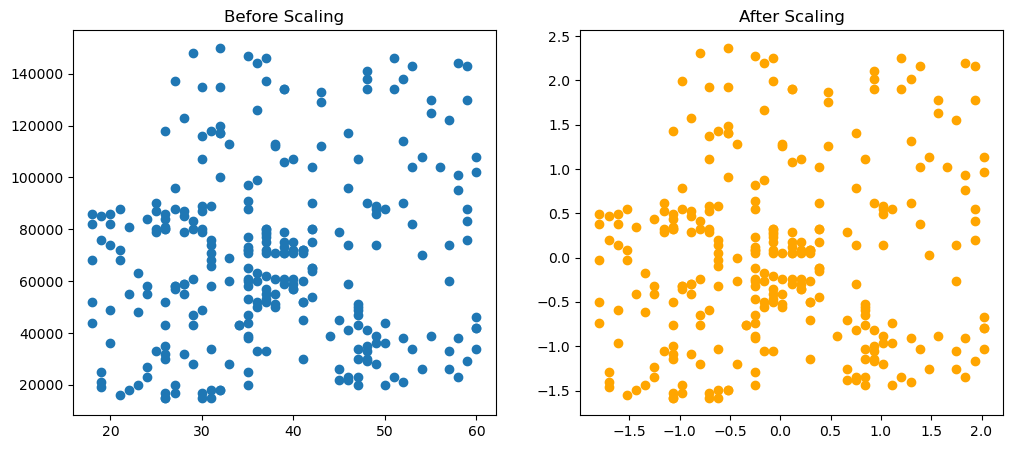

In [238]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='orange')
ax2.set_title('After Scaling')
plt.show()

C:\Users\123\AppData\Local\Temp\ipykernel_1516\3123778048.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


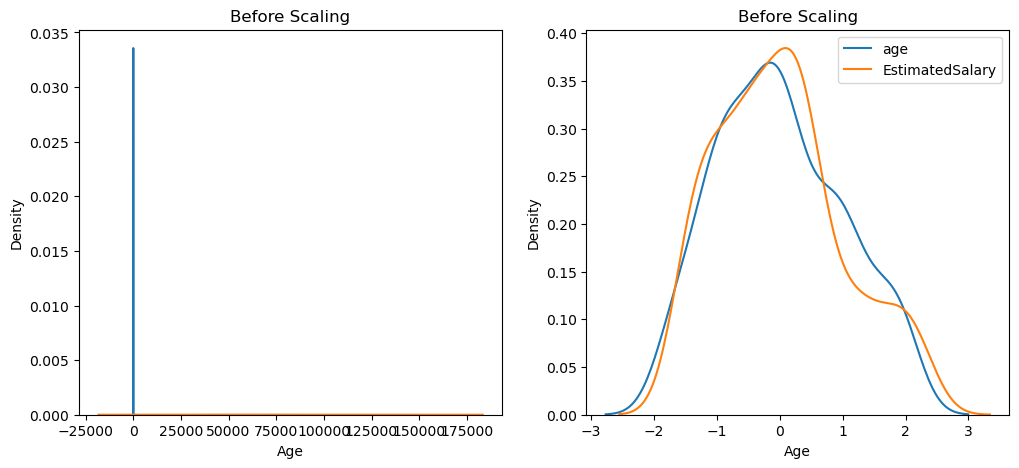

In [235]:
fig, (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

#before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax=ax1,label='age')
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1,label='EstimatedSalary')
plt.legend()


# after scaling
ax2.set_title('Before Scaling')
sns.kdeplot(x_train_scaled['Age'],ax=ax2,label='age')
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax=ax2,label='EstimatedSalary')
plt.legend()
plt.show()

Comparison of Distributions

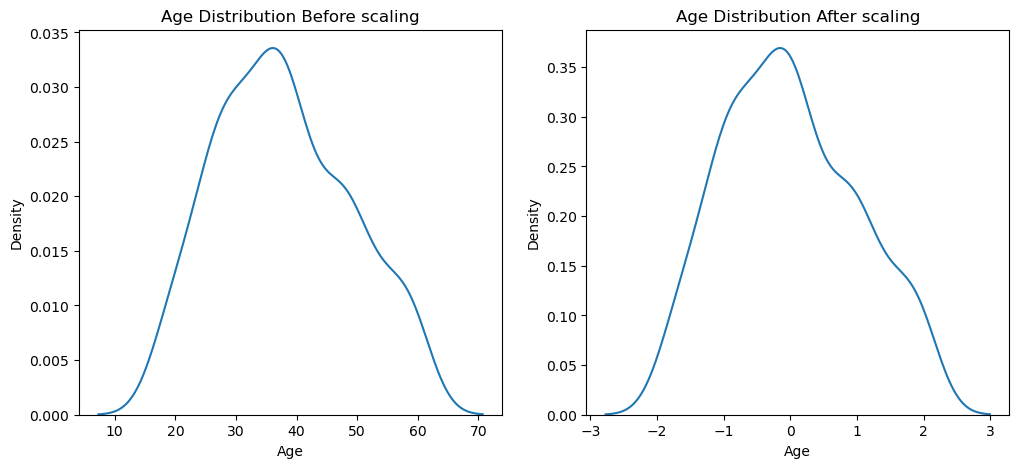

In [236]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# Before scaling
ax1.set_title('Age Distribution Before scaling')
sns.kdeplot(x_train['Age'],ax=ax1)

# after scaling
ax2.set_title('Age Distribution After scaling')
sns.kdeplot(x_train_scaled['Age'],ax=ax2)
plt.show()

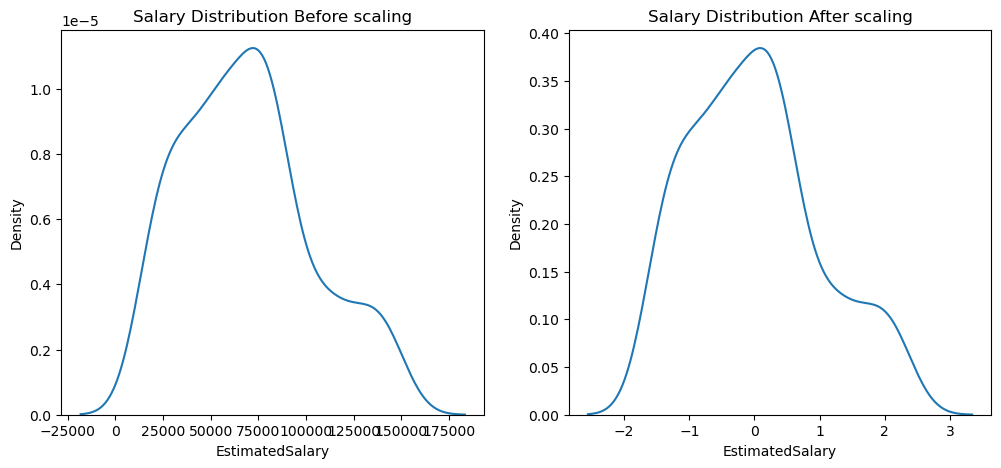

In [237]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# Before scaling
ax1.set_title('Salary Distribution Before scaling')
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)

# after scaling
ax2.set_title('Salary Distribution After scaling')
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()

Why scaling is important?

In [239]:
from sklearn.linear_model import LogisticRegression

In [240]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [241]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [242]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [243]:
from sklearn.metrics import accuracy_score

In [244]:
print("Actual",accuracy_score(y_test,y_pred))
print("scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8833333333333333
scaled 0.8916666666666667


In [246]:
from sklearn.tree import DecisionTreeClassifier

In [247]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [248]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

DecisionTreeClassifier()

In [252]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [253]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8666666666666667
Scaled 0.8666666666666667


In [254]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


Effect of Outlier

In [259]:
df = df.append(pd.DataFrame({'Age': [5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]}),ignore_index=True)

AttributeError: 'DataFrame' object has no attribute 'append'

In [260]:
new_rows = pd.DataFrame({ 'Age': [5, 90, 95], 'EstimatedSalary': [1000, 250000, 350000], 'Purchased': [0, 1, 1]})
df = pd.concat([df, new_rows], ignore_index=True)

In [261]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


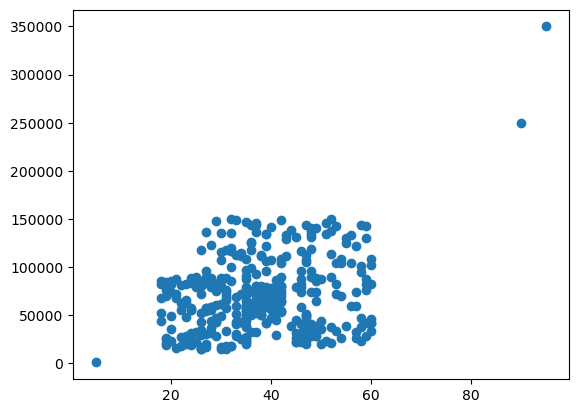

In [263]:
plt.scatter(df['Age'],df['EstimatedSalary'])

In [266]:
from sklearn.model_selection import train_test_split
x_train, x_test ,y_train, y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

x_train.shape,x_test.shape

((282, 2), (121, 2))

In [271]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

# transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [274]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled =  pd.DataFrame(x_test_scaled,columns=x_test.columns)

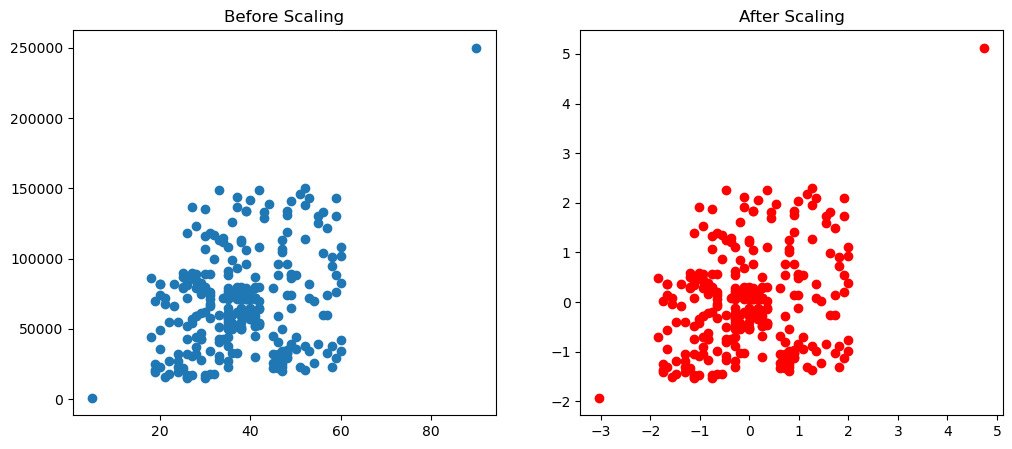

In [282]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title('After Scaling')
plt.show()